# State space generalized linear model (SS-GLM)
> Czanner, G., Eden, U.T., Wirth, S., Yanike, M., Suzuki, W.A., and Brown, E.N. (2008). Analysis of Between-Trial and Within-Trial Neural Spiking Dynamics. Journal of Neurophysiology 99, 2672–2693. https://doi.org/10.1152/jn.00343.2007.


In [ ]:
import jax
import jax.numpy as jnp


def log_conditional_intensity(design_matrix, params):
    return design_matrix @ params


def stochastic_point_process_filter(
    init_mean_params: jnp.ndarray,
    init_covariance_params: jnp.ndarray,
    design_matrix: jnp.ndarray,
    spike_indicator: jnp.ndarray,
    dt: float,
    transition_matrix: jnp.ndarray,
    covariance_matrix: jnp.ndarray,
    log_conditional_intensity: callable,
) -> tuple[jnp.ndarray, jnp.ndarray]:
    """Stochastic State Point Process Filter (SSPPF)

    Parameters
    ----------
    init_mode_params : jnp.ndarray, shape (n_params,)
        Initial mean parameters
    init_covariance_params : jnp.ndarray, shape (n_params, n_params)
        Initial variance parameters
    design_matrix : jnp.ndarray, shape (n_time, n_params)
    spike_indicator : jnp.ndarray, shape (n_time,)
        Spike count
    dt : float
        Time step
    transition_matrix : jnp.ndarray, shape (n_params, n_params)
    covariance_matrix : jnp.ndarray, shape (n_params, n_params)
    log_conditional_intensity : callable
        Function that takes in `design_matrix` and parameters and returns the log spike rate

    Returns
    -------
    posterior_mode : jnp.ndarray, shape (n_time, n_params)
    posterior_variance : jnp.ndarray, shape (n_time, n_params, n_params)

    References
    ----------
    ...[1] Eden, U. T., Frank, L. M., Barbieri, R., Solo, V. & Brown, E. N.
      Dynamic Analysis of Neural Encoding by Point Process Adaptive Filtering.
      Neural Computation 16, 971-998 (2004).


    """
    grad_log_conditional_intensity = jax.jacfwd(log_conditional_intensity, argnums=1)
    hess_log_conditional_intensity = jax.hessian(log_conditional_intensity, argnums=1)

    def _step(
        params_prev: tuple[jnp.ndarray, jnp.ndarray],
        args: tuple[jnp.ndarray, jnp.ndarray],
    ) -> tuple[tuple[jnp.ndarray, jnp.ndarray], tuple[jnp.ndarray, jnp.ndarray]]:
        """Point Process Adaptive Filter update step

        F : transition matrix
        Q : covariance matrix
        \theta_{k | k-1} :
        W_{k | k-1}: one_step_variance_params
        \theta_{k | k} : posterior_mode
        W_{k | k} : posterior_variance
        """

        # Unpack previous parameters
        mode_prev, variance_prev = params_prev
        design_matrix_t, spike_indicator_t = args

        # One-step prediction
        one_step_mode = transition_matrix @ mode_prev
        one_step_covariance = (
            transition_matrix @ variance_prev @ transition_matrix.T + covariance_matrix
        )

        # Compute the conditional intensity and innovation
        conditional_intensity = (
            jnp.exp(log_conditional_intensity(design_matrix_t, one_step_mode)) * dt
        )
        innovation = spike_indicator_t - conditional_intensity

        # Compute the posterior mean and variance
        one_step_grad = grad_log_conditional_intensity(design_matrix_t, one_step_mode)[
            None
        ]
        one_step_hess = hess_log_conditional_intensity(design_matrix_t, one_step_mode)

        inverse_posterior_covariance = (
            jnp.linalg.pinv(one_step_covariance)
            + (one_step_grad.T * conditional_intensity @ one_step_grad)
            - innovation * one_step_hess
        )
        posterior_covariance = jnp.linalg.pinv(inverse_posterior_covariance)
        posterior_mode = one_step_mode + posterior_covariance @ (
            one_step_grad.squeeze() * innovation
        )

        return (posterior_mode, posterior_covariance), (
            posterior_mode,
            posterior_covariance,
        )

    return jax.lax.scan(
        _step, (init_mean_params, init_covariance_params), (design_matrix, spike_indicator)
    )[1]


def stochastic_point_process_smoother(
    filtered_posterior_mode,
    filtered_posterior_covariance,
    one_step_mode,
    one_step_covariance,
    transition_matrix,
):

    def _step(params_prev, k):

        mode_smoothed_next, covariance_smoothed_next = params_prev
        smoother_gain = (
            filtered_posterior_covariance[k]
            @ transition_matrix.T
            @ jnp.linalg.pinv(one_step_covariance[k + 1])
        )
        # smoother_gain = jax.scipy.linalg.solve(
        #     one_step_covariance[k], filtered_posterior_covariance[k], assume_a="pos"
        # ).T

        mode_smoothed = filtered_posterior_mode[k] + smoother_gain @ (
            mode_smoothed_next - one_step_mode[k + 1]
        )

        covariance_smoothed = (
            filtered_posterior_covariance[k]
            + smoother_gain
            @ (covariance_smoothed_next - one_step_covariance[k + 1])
            @ smoother_gain.T
        )

        return (mode_smoothed, covariance_smoothed), (
            mode_smoothed,
            covariance_smoothed,
            smoother_gain,
        )

    init_params = (filtered_posterior_mode[-1], filtered_posterior_covariance[-1])
    n_time = len(filtered_posterior_mode)
    (_, _), (mode_smoothed, covariance_smoothed, smoother_gain) = jax.lax.scan(
        _step,
        init_params,
        jnp.arange(n_time - 1),
        reverse=True,
    )

    mode_smoothed = jnp.concatenate([mode_smoothed, filtered_posterior_mode[-1:]])
    covariance_smoothed = jnp.concatenate(
        [covariance_smoothed, filtered_posterior_covariance[-1:]]
    )

    return mode_smoothed, covariance_smoothed, smoother_gain

Text(0.5, 1.0, 'Simulated spikes')

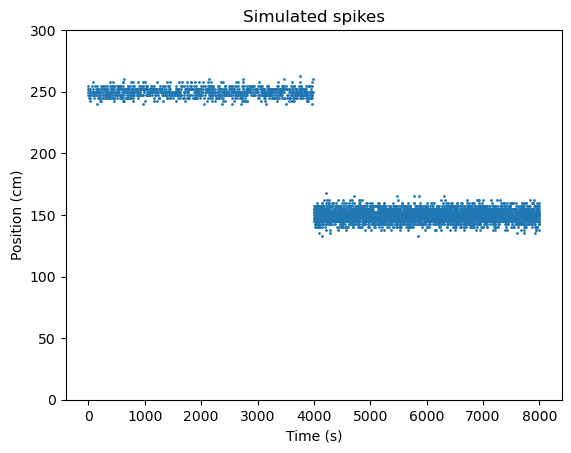

In [15]:
import numpy as np
import matplotlib.pyplot as plt


def log_receptive_field_model(position: np.ndarray, params: np.ndarray) -> np.ndarray:
    log_max_rate, place_field_center, scale = params
    return log_max_rate - (position - place_field_center) ** 2 / (2 * scale**2)


def receptive_field_model(position: np.ndarray, params: np.ndarray) -> np.ndarray:
    return np.exp(log_receptive_field_model(position, params))


def simulate_eden_brown_2004_jump():
    dt = 0.020  # seconds
    total_time = 8000.0  # seconds
    n_total_steps = int(total_time / dt)

    time = np.arange(0, total_time, dt)

    speed = 125.0  # cm/s
    track_length = 300.0  # cm

    run1 = np.arange(0, track_length, speed * dt)
    run2 = np.arange(track_length, 0, -speed * dt)
    run = np.concatenate((run1, run2))

    position = np.concatenate([run] * int(np.ceil(n_total_steps / run.shape[0])))
    position = position[:n_total_steps]

    true_params1 = np.array([np.log(10.0), 250.0, np.sqrt(12.0)])
    true_params2 = np.array([np.log(30.0), 150.0, np.sqrt(20.0)])
    true_rate1 = receptive_field_model(position[: position.shape[0] // 2], true_params1)
    true_rate2 = receptive_field_model(position[position.shape[0] // 2 :], true_params2)
    true_rate = np.concatenate((true_rate1, true_rate2))
    spike_indicator = np.random.poisson(true_rate * dt)

    return time, position, spike_indicator, dt, true_params1, true_params2


time, position, spike_indicator, dt, true_params1, true_params2 = (
    simulate_eden_brown_2004_jump()
)

plt.scatter(
    time[spike_indicator.nonzero()[0]], position[spike_indicator.nonzero()[0]], s=1
)
plt.ylim((0, 300))
plt.ylabel("Position (cm)")
plt.xlabel("Time (s)")
plt.title("Simulated spikes")

In [16]:
from patsy import dmatrix


model_formula = "bs(x, df=6, degree=3, include_intercept=True) - 1"
design_matrix = dmatrix(model_formula, {"x": position})
design_matrix = jnp.asarray(design_matrix)
design_matrix.shape

(400000, 6)

In [38]:
n_params = design_matrix.shape[1]

transition_matrix = np.identity(n_params)
covariance_matrix = np.identity(n_params) * 1e-3
# init_mode_params = np.random.rand(n_params)
init_mode_params = np.zeros(n_params)
init_covariance_params = np.identity(n_params)

(
    posterior_mode,
    posterior_covariance,
) = stochastic_point_process_filter(
    init_mean_params=init_mode_params,
    init_covariance_params=init_covariance_params,
    design_matrix=design_matrix,
    spike_indicator=spike_indicator,
    dt=dt,
    transition_matrix=transition_matrix,
    covariance_matrix=covariance_matrix,
    log_conditional_intensity=log_conditional_intensity,
)

/Users/edeno/miniconda3/envs/state_space_practice/lib/python3.10/site-packages/matplotlib/colors.py:732: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


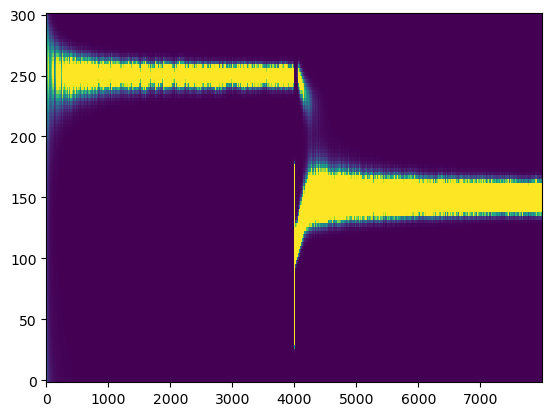

In [39]:
x = np.linspace(position.min(), position.max(), 100)
predict_matrix = dmatrix(model_formula, {"x": x})

posterior_mode.shape, predict_matrix.shape
prediction = jnp.exp(posterior_mode @ predict_matrix.T) / dt

t, p = np.meshgrid(time, x)

plt.pcolormesh(t, p, prediction.T, vmin=0.0, vmax=100.0)

In [40]:
from state_space_practice.switching_kalman import _kalman_smoother_update


def smoother(
    filter_mean,
    filter_cov,
    process_cov,
    transition_matrix,
):
    def _step(carry, args):
        (
            next_smoother_mean,
            next_smoother_cov,
        ) = carry

        filter_mean, filter_cov = args

        smoother_mean, smoother_cov, smoother_cross_cov = _kalman_smoother_update(
            next_smoother_mean,
            next_smoother_cov,
            filter_mean,
            filter_cov,
            process_cov,
            transition_matrix,
        )
        return (
            smoother_mean,
            smoother_cov,
        ), (
            smoother_mean,
            smoother_cov,
            smoother_cross_cov,
        )

    (_, _), (smoother_mean, smoother_cov, smoother_cross_cov) = jax.lax.scan(
        _step,
        (filter_mean[-1], filter_cov[-1]),
        (filter_mean[:-1], filter_cov[:-1]),
        reverse=True,
    )

    smoother_mean = jnp.concatenate((smoother_mean, filter_mean[-1][None]))
    smoother_cov = jnp.concatenate((smoother_cov, filter_cov[-1][None]))

    return smoother_mean, smoother_cov, smoother_cross_cov


smoother_mean, smoother_cov, smoother_cross_cov = smoother(
    posterior_mode,
    posterior_covariance,
    covariance_matrix,
    transition_matrix,
)

/Users/edeno/miniconda3/envs/state_space_practice/lib/python3.10/site-packages/matplotlib/colors.py:732: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


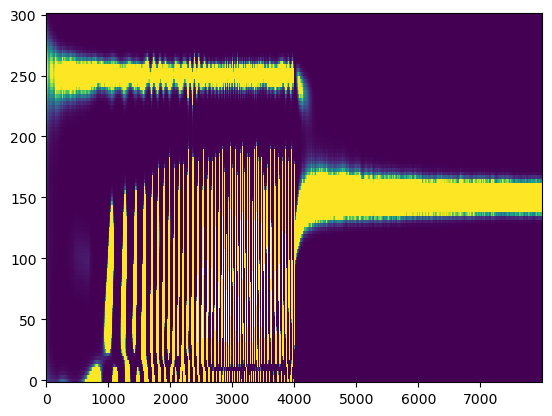

In [41]:
smoother_prediction = jnp.exp(smoother_mean @ predict_matrix.T) / dt

plt.pcolormesh(t, p, smoother_prediction.T, vmin=0.0, vmax=100.0)

In [47]:


mode_smoothed, covariance_smoothed, _ = stochastic_point_process_smoother(
    posterior_mode,
    posterior_covariance,
    one_step_mode,
    one_step_covariance,
)

/Users/edeno/miniconda3/envs/state_space_practice/lib/python3.10/site-packages/matplotlib/colors.py:732: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


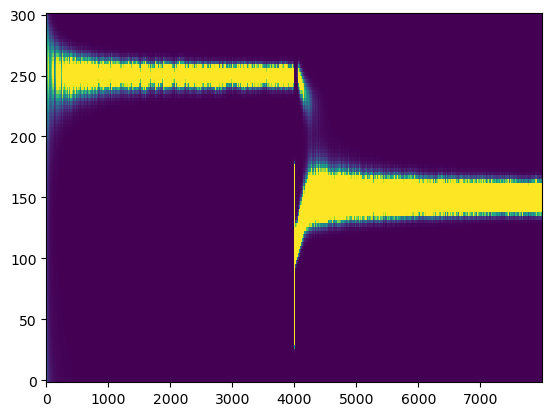

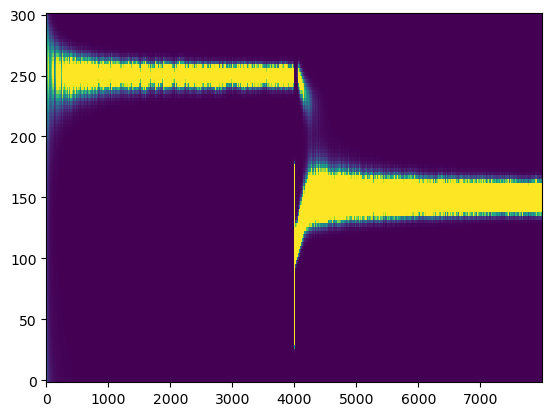

In [49]:
smoother_prediction2 = jnp.exp(mode_smoothed @ predict_matrix.T) / dt

plt.pcolormesh(t, p, smoother_prediction2.T, vmin=0.0, vmax=100.0)
plt.figure()
plt.pcolormesh(t, p, prediction.T, vmin=0.0, vmax=100.0)